# TEMPO and CAM-chem-se with UXARRAY directly

First we need to import the driver.

In [1]:
from melodies_monet import driver

In [2]:
# Needed if you want to make changes to `melodies_monet` and don't want to restart kernel:
%load_ext autoreload

%autoreload 2

## Initiate the analysis class

Now lets create an instance of the {mod}`melodies_monet.driver` {class}`~melodies_monet.driver.analysis` class.
It consists of 4 main parts: model instances, observation instances, a paired instance of both.
This will allow us to move things around the plotting function for spatial and overlays and more complex plots.

In [3]:
an = driver.analysis()
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control File

Read in the required yaml control file that sets up all the definitions of what we want to pair and plot.

In [4]:
an.control = '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/control_tempo_l2_no2_cesm_se_20240101.yaml'
an.read_control()
an.control_dict

{'analysis': {'start_time': '2024-01-01',
  'end_time': '2024-01-02',
  'output_dir': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/output/tempo_camchemse',
  'output_dir_save': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/output/tempo_camchemse',
  'output_dir_read': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/output/tempo_camchemse',
  'save': {'paired': {'method': 'netcdf',
    'prefix': '20240101',
    'data': 'all'}},
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'tempo_l2_no2_cam-chem-se': ['tempo_l2_no2_cam-chem-se']}}},
  'debug': False},
 'obs': {'tempo_l2_no2': {'debug': False,
   'filename': '/glade/derecho/scratch/jjacdan/TEMPO/TEMPO_NO2_L2_V03_20240101T12*Z_S001G0[1-3].nc',
   'obs_type': 'sat_swath_clm',
   'sat_type': 'tempo_l2_no2',
   'variables': {'main_data_quality_flag'

## Load the model data 

The driver will automatically loop through the "models" found in the model section of the control file and create model classes for each. Classes include the label, mapping information, and xarray object as well as the filenames.  Note it can open multiple files easily by including wildcards. Here we are only opening one CAM-chem file.

In [5]:
an.open_models()

Scrip file /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
cesm_se
['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc']
**** Reading CESM SE model output...
Using UXArray grid file: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
Using SCRIP file: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
Opening unstructured grid with UXArray: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc


/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CESM-SE: requested variables not found in '/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc': ['P0']. Continuing with what's available: ['NO2', 'lat', 'lon', 'lev', 'hyam', 'hybm', 'PS', 'T', 'PDELDRY'].
**** Opened uxarray grid: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc


In [6]:
an.models

{'cam-chem-se': model(
     model='cesm_se',
     is_global=False,
     radius_of_influence=1000000.0,
     mod_kwargs={'var_list': ['NO2', 'lat', 'lon', 'lev', 'hyam', 'hybm', 'PS', 'P0', 'T', 'PDELDRY'], 'scrip_file': '/glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc'},
     file_str=['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc'],
     label='cam-chem-se',
     obj=...,
     extra_calc=None,
     mapping={'tempo_l2_no2': {'NO2': 'vertical_column_troposphere'}},
     variable_dict=None,
     label='cam-chem-se',
     ...
 )}

In [7]:
an.models['cam-chem-se'].obj

<xarray.UxDataset> Size: 3GB
Dimensions:        (z: 32, time: 24, n_face: 174098)
Coordinates:
  * z              (z) float64 256B 992.6 976.3 957.5 ... 14.36 7.595 3.643
  * time           (time) datetime64[ns] 192B 2024-01-01T01:00:00 ... 2024-01-02
    latitude       (n_face) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
    longitude      (n_face) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
Dimensions without coordinates: n_face
Data variables:
    NO2            (time, z, n_face) float32 535MB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    pres_pa_mid    (z, time, n_face) float64 1GB dask.array<chunksize=(32, 24, 174098), meta=np.ndarray>
    temperature_k  (time, z, n_face) float32 535MB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    dz_m           (time, z, n_face) float64 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
Attributes: (12/13)
    ne:                         0
    np:                         4
    Conventions:                CF-1.0
    source:                     CAM
    case:                       f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_...
    logname:                    gaubert
    ...                         ...
    initial_file:               /glade/campaign/cesm/cesmdata/inputdata/atm/c...
    topography_file:            /glade/campaign/cesm/cesmdata/inputdata/atm/c...
    model_doi_url:              https://doi.org/10.5065/D67H1H0V
    time_period_freq:           hour_1
    mio_has_unstructured_grid:  True
    mio_scrip_file:             /glade/campaign/acom/MUSICA/grids/ne0CONUSne3...

In [8]:
# All the info in the model class can be called here.
print(an.models['cam-chem-se'].label)
print(an.models['cam-chem-se'].mapping)

cam-chem-se
{'tempo_l2_no2': {'NO2': 'vertical_column_troposphere'}}


In [9]:
# All the info in the analysis class can also be called.
print(an.start_time)
print(an.end_time)
print(an.download_maps)

2024-01-01 00:00:00
2024-01-02 00:00:00
True


## Open Obs

Now for monet-analysis we will open preprocessed data in either netcdf icartt or some other format.  We will not be retrieving data like monetio does for some observations (ie aeronet, airnow, etc....).  Instead we will provide utitilies to do this so that users can add more data easily.

Like models we list all obs objects in the yaml file and it will loop through and create driver.observation instances that include the model type, file, objects (i.e. data object) and label  

In [10]:
an.control_dict['obs']

{'tempo_l2_no2': {'debug': False,
  'filename': '/glade/derecho/scratch/jjacdan/TEMPO/TEMPO_NO2_L2_V03_20240101T12*Z_S001G0[1-3].nc',
  'obs_type': 'sat_swath_clm',
  'sat_type': 'tempo_l2_no2',
  'variables': {'main_data_quality_flag': {'main_data_quality_flag_max': 0,
    'var_applied': ['vertical_column_troposphere']},
   'vertical_column_troposphere': {'ylabel_plot': 'NO2 trop. column',
    'vmin_plot': -4,
    'vmax_plot': 4},
   'pressure': {},
   'tropopause_pressure': {},
   'scattering_weights': {},
   'amf_troposphere': {}}}}

In [11]:
an.open_obs()

Reading TEMPO L2
/glade/derecho/scratch/jjacdan/TEMPO/TEMPO_NO2_L2_V03_20240101T12*Z_S001G0[1-3].nc


/glade/u/home/lcthompson/mm/monetio/monetio/monetio/sat/tempo_l2.py:205: UserWarning: Calculating pressure in TEMPO data requires surface_pressure. Adding surface_pressure to output variables
  warnings.warn(


In [12]:
# All the info in the observation class can also be called.
#an.obs['tempo_l2_no2'].obj

## Pair model and obs data

In [13]:
%%time

# lat lon are data variables and not coords?? 
# model_obj = an.models['cam-chem-se'].obj
# model_obj = model_obj.rename({'lon': 'longitude', 'lat': 'latitude'})
# model_obj_fixed = model_obj.set_coords(['latitude', 'longitude'])
# an.models['cam-chem-se'].obj = model_obj_fixed

# somethibg with the lat lon renaming thing. 
an.pair_data()

1, in pair data
Regridding 2024-01-01T12:51:57Z and applying AMF and weights


/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


  rss=1.42 GB
Regridding 2024-01-01T12:58:37Z and applying AMF and weights


/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


  rss=1.42 GB


/glade/u/home/lcthompson/mm/MELODIES-MONET/melodies_monet/util/uxarray_util.py:342: RuntimeWarning: Mean of empty slice
  out_arr[..., ti] = np.nanmean(arr[..., sources], axis=-1)


CPU times: user 13.3 s, sys: 4.85 s, total: 18.2 s
Wall time: 30.5 s


In [14]:
an.paired

{'tempo_l2_no2_cam-chem-se': pair(
     type='sat_swath_clm',
     radius_of_influence=1000000.0,
     obs='tempo_l2_no2',
     model='cam-chem-se',
     model_vars=['NO2'],
     obs_vars=['vertical_column_troposphere'],
     filename='tempo_l2_no2_cam-chem-se.nc',
 )}

In [15]:
an.paired['tempo_l2_no2_cam-chem-se'].obj

<xarray.Dataset> Size: 6MB
Dimensions:                      (time: 1, target: 174098)
Coordinates:
  * time                         (time) datetime64[ns] 8B 2024-01-01T12:51:57
    longitude                    (target) float64 1MB -125.6 -125.3 ... -60.71
    latitude                     (target) float64 1MB 6.166 6.049 ... 47.14
Dimensions without coordinates: target
Data variables:
    NO2                          (time, target) float64 1MB nan ... 1.246e+15
    vertical_column_troposphere  (time, target) float64 1MB nan ... -2.349e+14
    end_time                     (time) datetime64[ns] 8B 2024-01-01T13:05:29...

## Generate plots

{'color': 'k', 'linestyle': '-', 'marker': '*', 'linewidth': 2.0, 'markersize': 10.0, 'label': 'tempo_l2_no2', 'fontsize': 14.4}
0 1e+16
0 1e+16
0 1e+16
0 1e+16
Base standard deviation:  1.45e+15
Reference std: 1
CPU times: user 1min 24s, sys: 2.26 s, total: 1min 26s
Wall time: 1min 36s


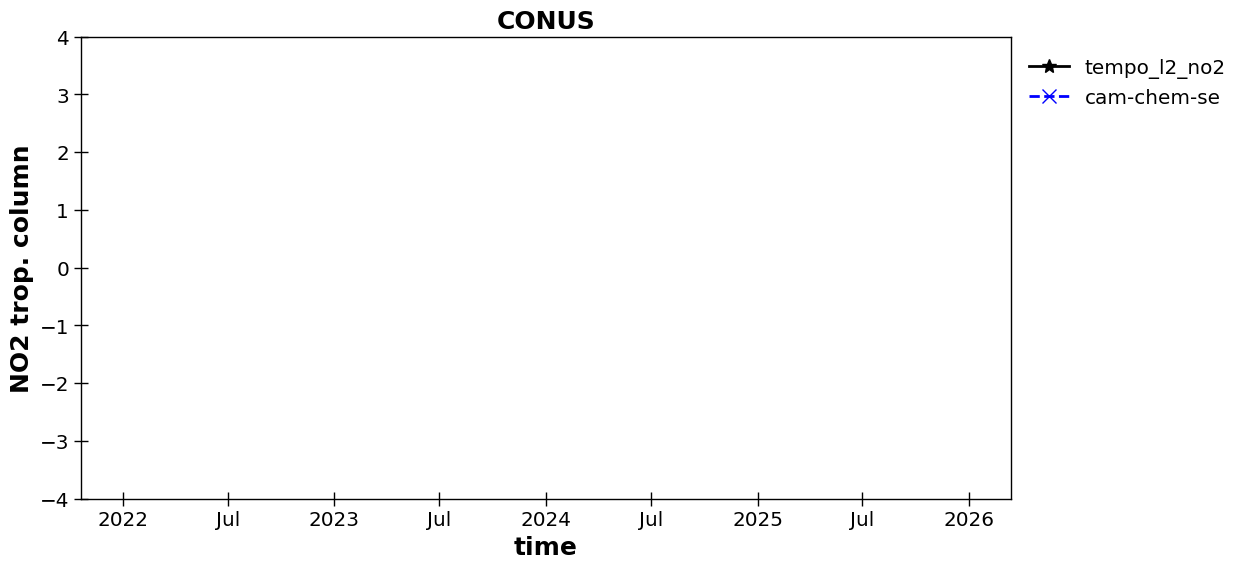

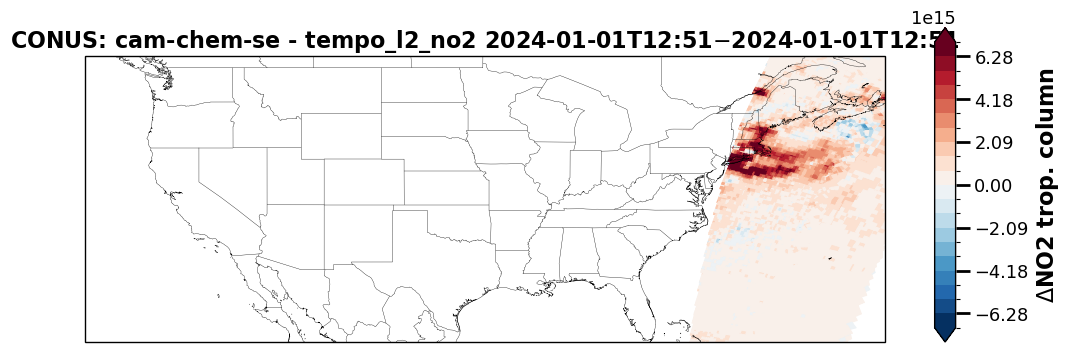

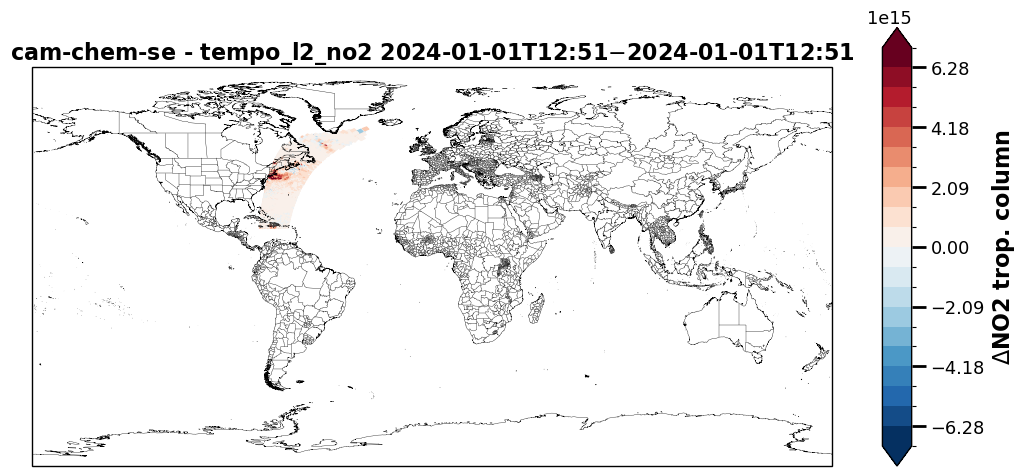

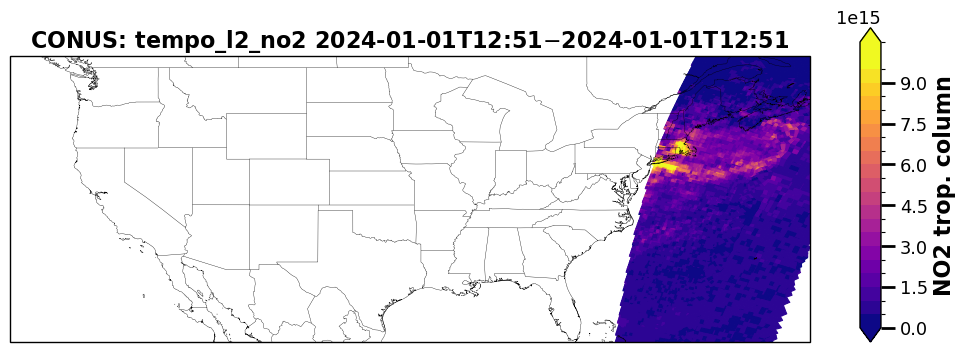

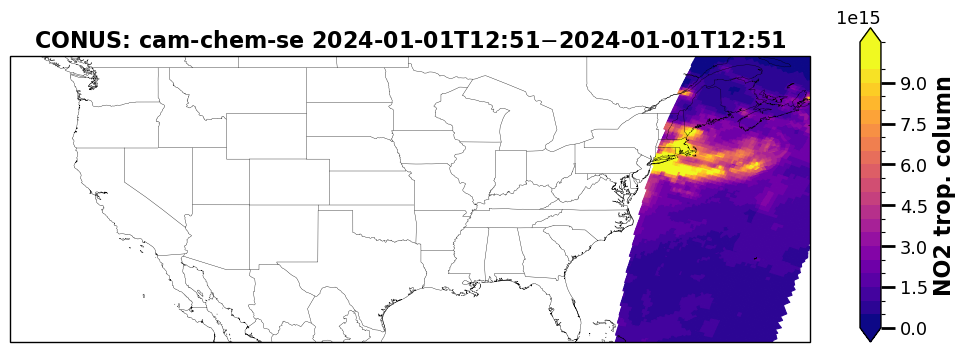

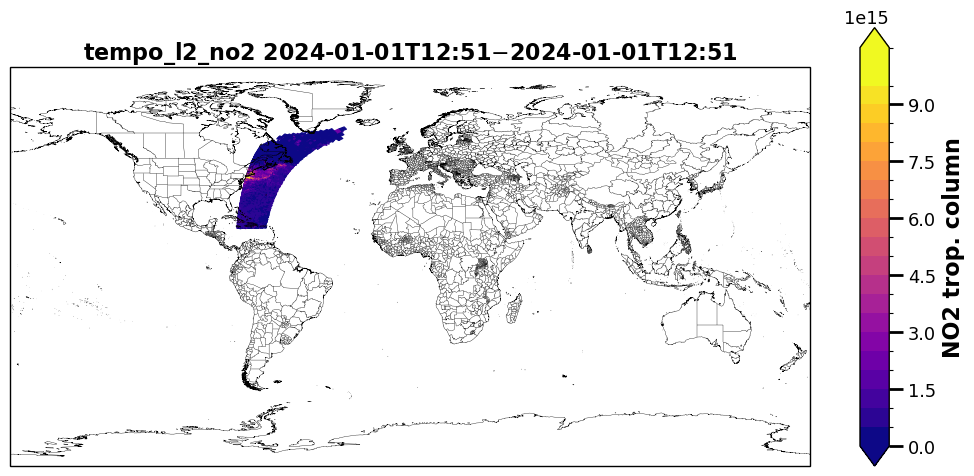

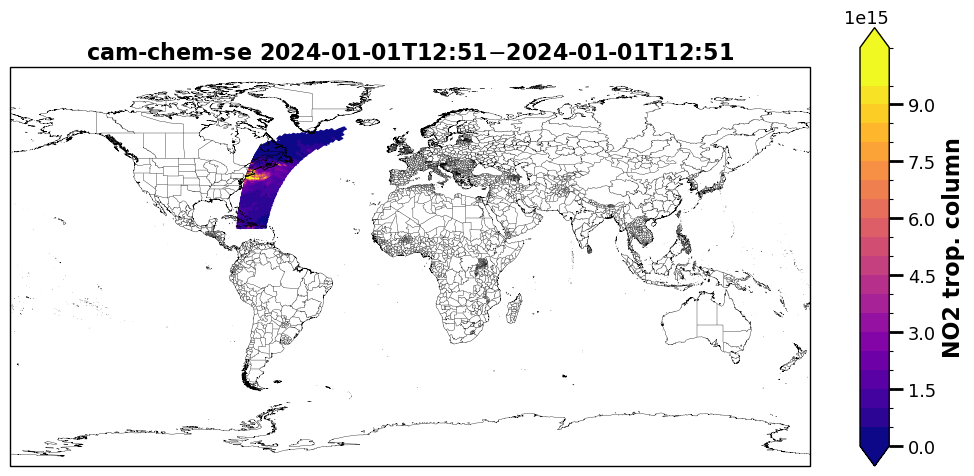

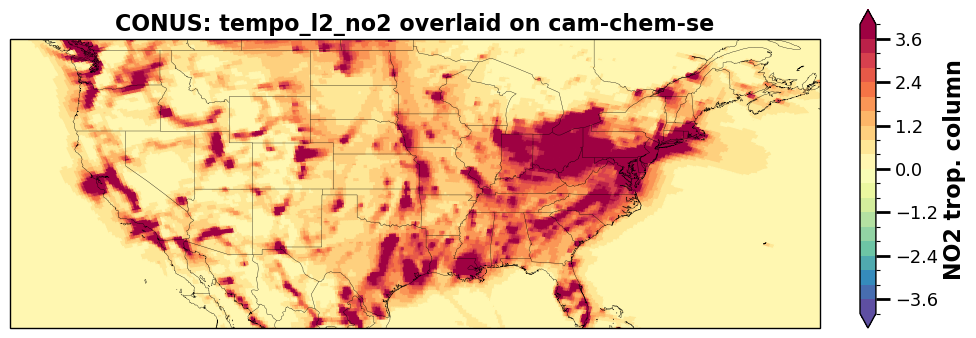

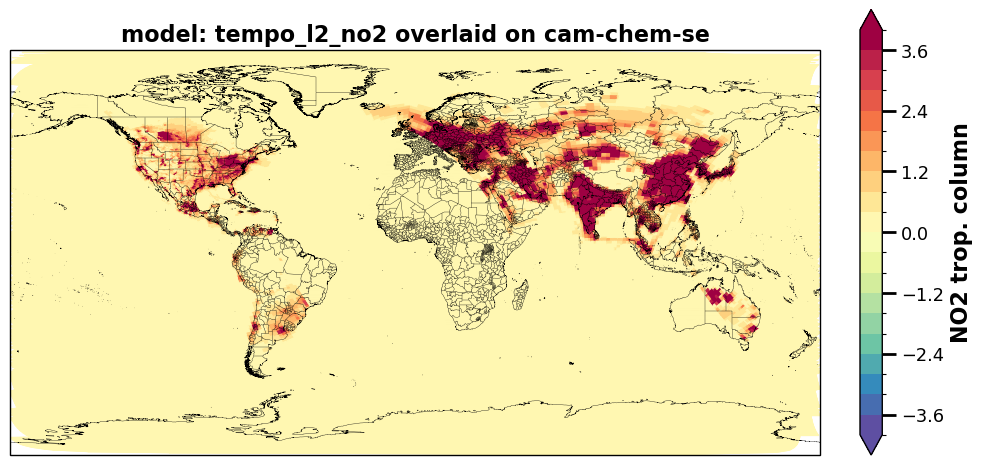

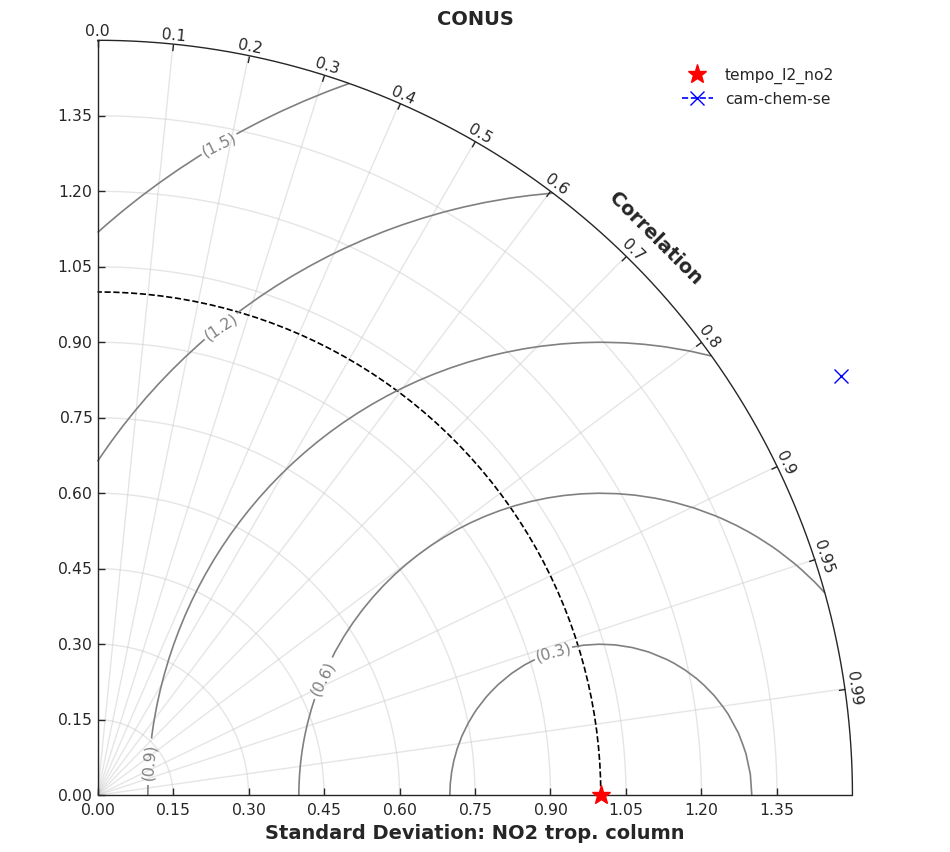

In [16]:
%%time

an.plotting()

**10 Figures**

::::{card-carousel} 10

:::{card} Figure 1
:img-background: output/camchem/plot_grp1.timeseries.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 2
:img-background: output/camchem/plot_grp1.timeseries.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

:::{card} Figure 3
:img-background: output/camchem/plot_grp2.taylor.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 4
:img-background: output/camchem/plot_grp2.taylor.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

:::{card} Figure 5
:img-background: output/camchem/plot_grp3.spatial_bias.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 6
:img-background: output/camchem/plot_grp3.spatial_bias.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 7
:img-background: output/camchem/plot_grp4.spatial_overlay.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 8
:img-background: output/camchem/plot_grp4.spatial_overlay.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 9
:img-background: output/camchem/plot_grp5.boxplot.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 10
:img-background: output/camchem/plot_grp5.boxplot.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

::::